<a href="https://colab.research.google.com/github/DIFACQUIM/antiviral_ML/blob/main/01_Get_compounds_ChEMBL_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

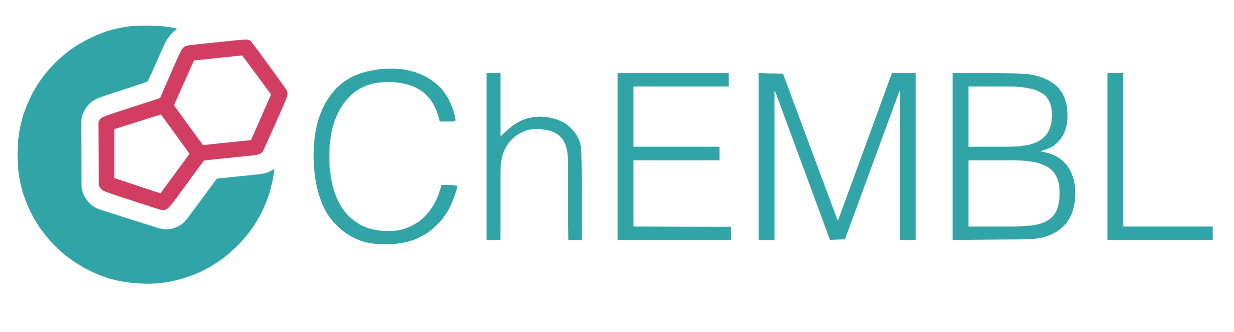

---
**Made by:** Raziel Cedillo
**Mail:** brayanraziel1997@gmail.com
(June 2023, February 2024)
---


---

# **Packages**: installation and importation
---


In [ ]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        from tqdm import tqdm
        pbar.update(20)
        !pip install matplotlib, seaborn, pandas
        import matplotlib.pyplot as plt
        from IPython.display import display, SVG, HTML
        import seaborn as sns
        !pip install rdkit
        from rdkit import Chem
        from rdkit.Chem import Draw, Descriptors
        from rdkit.Chem.rdmolops import RemoveStereochemistry

        pbar.update(40)
        import pandas as pd
        %config Completer.use_jedi = False
        import json
        pbar.update(30)
        !pip install chembl_webresource_client
        from chembl_webresource_client.new_client import new_client
        from chembl_webresource_client.utils import utils
        from pathlib import Path

        !pip install molvs
        !pip install datamol
        import datamol as dm
        from matplotlib_venn import venn3, venn3_circles, venn3_unweighted
        dm.disable_rdkit_log()
        from molvs.standardize import Standardizer
        from molvs.charge import Uncharger, Reionizer
        from molvs.fragment import LargestFragmentChooser
        from molvs.tautomer import TautomerCanonicalizer
        from rdkit.Chem.rdmolops import GetFormalCharge, RemoveStereochemistry
        from rdkit import RDConfig
        from rdkit import Chem, DataStructs
        from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors, Descriptors3D, rdMolDescriptors, Scaffolds,MACCSkeys
        from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
        from rdkit.DataManip.Metric.rdMetricMatrixCalc import GetTanimotoSimMat, GetTanimotoDistMat
        PandasTools.RenderImagesInAllDataFrames(images=True)
        from rdkit.Chem.Draw import IPythonConsole
        from google.colab import drive
        drive.mount('/content/drive')
        pbar.update(10)

  0%|          | 0/100 [00:00<?, ?it/s]

---

# **1. Target identification**


---



In [ ]:
#The next lines decompose the physicochemical properties of interest, of the molecules that meet the previous filters.
def desglose_informacion(column_name_output='',column_name_input='' ):
  df[column_name_output]= df.loc[df[column_name_input].notnull(),column_name_input].apply(lambda x: x[column_name_output])
  return df

In [ ]:
farmaco = new_client.drug
actividad = new_client.activity
blanco_molecular = new_client.target
molecula=new_client.molecule
indicacion = new_client.drug_indication

## **1.1 Disease**


In [ ]:
efo_vir = indicacion.filter(efo_term__icontains="vir")
print(len(efo_vir))
efo_vir_df= pd.DataFrame.from_records(efo_vir)
efo_vir_df_ls=efo_vir_df['molecule_chembl_id'].tolist()
efo_vir_df[0:2]

723


,drugind_id,efo_id,efo_term,indication_refs,max_phase_for_ind,mesh_heading,mesh_id,molecule_chembl_id,parent_molecule_chembl_id
0,22897,EFO:0003047,hepatitis C virus infection,"[{'ref_id': 'NCT02053519', 'ref_type': 'Clinic...",3.0,Hepatitis C,D006526,CHEMBL1042,CHEMBL1042
1,22897,EFO:0003047,hepatitis C virus infection,"[{'ref_id': 'NCT02053519', 'ref_type': 'Clinic...",3.0,Hepatitis C,D006526,CHEMBL1042,CHEMBL1042


In [ ]:
print(len(efo_vir_df['mesh_heading'].unique()))
print(efo_vir_df['mesh_heading'].unique())

31
['Hepatitis C' 'Hepatitis B, Chronic' 'Hepatitis C, Chronic'
 'Virus Diseases' 'Hepatitis, Viral, Human' 'Cytomegalovirus Infections'
 'Hepatitis D' 'Hepatitis B' 'Respiratory Syncytial Virus Infections'
 'Rotavirus Infections' 'Papillomavirus Infections' 'HTLV-I Infections'
 'Keratitis, Herpetic' 'Cytomegalovirus Retinitis' 'Hantavirus Infections'
 'Paramyxoviridae Infections' 'Hepatitis A' 'Stomatitis, Herpetic'
 'Adenoviridae Infections' 'Conjunctivitis, Viral'
 'Epstein-Barr Virus Infections' 'Hepatitis E' 'Pneumonia, Viral'
 'Coronavirus Infections' 'Hepadnaviridae Infections'
 'Zika Virus Infection' 'Rubulavirus Infections'
 'Orthomyxoviridae Infections' 'Rhabdoviridae Infections'
 'Respiratory Syncytial Viruses' 'Hepatitis D, Chronic']


In [ ]:
print(efo_vir_df['efo_term'].unique())

['hepatitis C virus infection' 'chronic hepatitis B virus infection'
 'chronic hepatitis C virus infection' 'hepatitis B virus infection'
 'viral disease' 'viral human hepatitis infection'
 'cytomegalovirus infection' 'hepatitis D virus infection'
 'Respiratory Syncytial Virus Infection' 'rotavirus infection'
 'human papilloma virus infection'
 'Human T-lymphotropic virus 1 infectious disease'
 'Herpes simplex virus keratitis' 'Cytomegalovirus Retinitis'
 'Hantavirus infectious disease' 'Paramyxoviridae infectious disease'
 'hepatitis A virus infection' 'Herpes simplex virus gingivostomatitis'
 'Adenoviridae Infections' 'viral conjunctivitis'
 'Epstein-Barr virus infection' 'hepatitis E virus infection'
 'viral pneumonia' 'coronavirus infectious disease'
 'Hepadnaviridae infectious disease' 'Zika virus infectious disease'
 'Mumps virus infectious disease' 'Orthomyxoviridae infectious disease'
 'Rhabdoviridae infectious disease']


## **1.2 Mechanism**


In [ ]:
mecanismo = new_client.mechanism
name_list =['vir', 'virus', 'viral']
columns = ['action_type','max_phase','mechanism_comment',
                              'mechanism_of_action','molecule_chembl_id', 'target_chembl_id']
all_mex_records = []
for name in name_list:
  res1 = mecanismo.filter(mechanism_comment__icontains=name)
  print(f"La palabra clave '{name}' presenta {len(res1)} entradas")
  all_mex_records.extend(res1)
mx_df= pd.DataFrame.from_records(all_mex_records)
mx_df_1 = mx_df.drop_duplicates(subset=['target_chembl_id','record_id'])
mx_target_id=mx_df_1['target_chembl_id'].tolist()
print(len(mx_df))
print(len(mx_target_id))
mx_df

La palabra clave 'vir' presenta 44 entradas
La palabra clave 'virus' presenta 18 entradas
La palabra clave 'viral' presenta 32 entradas
94
44


,action_type,binding_site_comment,direct_interaction,disease_efficacy,max_phase,mec_id,mechanism_comment,mechanism_of_action,mechanism_refs,molecular_mechanism,molecule_chembl_id,parent_molecule_chembl_id,record_id,selectivity_comment,site_id,target_chembl_id,variant_sequence
0,INHIBITOR,None,1,1,4,1290,Antiviral activity,Matrix protein 2 inhibitor,[{'ref_id': 'setid=a2caed21-e9a3-228e-70a8-de3...,1,CHEMBL1569,CHEMBL660,1344319,None,NaN,CHEMBL1932894,None
1,INHIBITOR,None,1,1,4,1409,Seems to prevent the fusion between the host m...,Envelope glycoprotein inhibitor,[{'ref_id': 'http://libsta28.lib.cam.ac.uk:211...,1,CHEMBL1200453,CHEMBL1200453,1344208,None,NaN,CHEMBL2364696,None
2,INHIBITOR,None,1,1,4,1930,Virustatic antimetabolites; recent studies ind...,DNA inhibitor,"[{'ref_id': '0-86577-843-4 PP. 284', 'ref_type...",1,CHEMBL1129,CHEMBL1129,1343825,None,NaN,CHEMBL2366042,None
3,INHIBITOR,None,1,1,4,2421,Prodrug of tenofovir; active metabolite tenofo...,Human immunodeficiency virus type 1 reverse tr...,[{'ref_id': 'setid=34784acf-15ed-4715-b504-eb3...,1,CHEMBL2364637,CHEMBL2107825,1879163,None,NaN,CHEMBL247,None
4,INHIBITOR,Binds to fibroblast growth factor 1 in a hydro...,1,1,3,5890,Potent inhibitor of fibroblast growth factor-i...,Acidic fibroblast growth factor inhibitor,"[{'ref_id': '8514', 'ref_type': 'PubChem', 're...",1,CHEMBL413376,CHEMBL265502,1699551,None,NaN,CHEMBL2120,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,INHIBITOR,None,1,1,4,8613,This drug is a viral protease inhibitor but in...,Cytochrome P450 3A inhibitor,"[{'ref_id': 'label/2000/21226lbl.pdf', 'ref_ty...",1,CHEMBL163,CHEMBL163,1344978,None,NaN,CHEMBL2364675,None
90,INHIBITOR,Alpha subunit,1,1,4,8971,May also have antiviral and anticancer effects...,Sodium/potassium-transporting ATPase inhibitor,"[{'ref_id': '31783627', 'ref_type': 'PubMed', ...",1,CHEMBL506569,CHEMBL506569,1702455,None,2653.0,CHEMBL2095186,None
91,DISRUPTING AGENT,None,1,1,2,9109,Possibly also binds to heparan sulfate proteog...,Membrane disrupting agent,"[{'ref_id': '33572467', 'ref_type': 'PubMed', ...",1,CHEMBL2219413,CHEMBL2219413,1763601,None,NaN,CHEMBL4662968,None
92,EXOGENOUS GENE,None,1,1,4,9730,Autologous CD34+ cells with retrovirally deliv...,ADA exogenous gene,[{'ref_id': 'https://www.ema.europa.eu/en/docu...,1,CHEMBL5315093,CHEMBL5315093,3956758,None,NaN,CHEMBL5303724,None


## **1.3 Organism**


In [ ]:
blanco_molecular = new_client.target
name_list =['vir', 'virus', 'viral']
#columns = ['organism',	'pref_name','target_chembl_id','target_type']
all_target_records = []
for name in name_list:
    res = blanco_molecular.filter(organism__icontains=name)#.only(columns)
    print(f"La palabra clave '{name}' presenta {len(res)} entradas")
    all_target_records.extend(res)
org_vir_df = pd.DataFrame.from_records(all_target_records)
org_vir_list=org_vir_df['target_chembl_id'].tolist()
print(f"Lista de Target IDs: {len(org_vir_list)}")
org_vir_df

La palabra clave 'vir' presenta 514 entradas
La palabra clave 'virus' presenta 496 entradas
La palabra clave 'viral' presenta 2 entradas
Lista de Target IDs: 1012


,cross_references,organism,pref_name,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,CHEMBL2051,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044
1,"[{'xref_id': 'P63231', 'xref_name': None, 'xre...",Influenza A virus (A/Udorn/307/1972(H3N2)),Influenza virus A matrix protein M2,False,CHEMBL2052,"[{'accession': 'P0DOF8', 'component_descriptio...",SINGLE PROTEIN,381517
2,"[{'xref_id': 'P04293', 'xref_name': None, 'xre...",Herpes simplex virus (type 1 / strain 17),Human herpesvirus 1 DNA polymerase,False,CHEMBL1872,"[{'accession': 'P04293', 'component_descriptio...",SINGLE PROTEIN,10299
3,[],Hepatitis B virus adw2/Southern-Africa/Cai,Major surface antigen,False,CHEMBL1928,"[{'accession': 'P31873', 'component_descriptio...",SINGLE PROTEIN,489449
4,"[{'xref_id': 'Q72874', 'xref_name': None, 'xre...",Human immunodeficiency virus 1,Human immunodeficiency virus type 1 protease,False,CHEMBL243,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676
...,...,...,...,...,...,...,...,...
1007,[],Variola virus,Envelope phospholipase OPG057,False,CHEMBL5308522,"[{'accession': 'P33815', 'component_descriptio...",SINGLE PROTEIN,10255
1008,[],Monkeypox virus,Envelope phospholipase OPG057,False,CHEMBL5308523,"[{'accession': 'A0A7H0DN30', 'component_descri...",SINGLE PROTEIN,10244
1009,[],Cowpox virus,Envelope phospholipase OPG057,False,CHEMBL5308524,"[{'accession': 'G0XSE7', 'component_descriptio...",SINGLE PROTEIN,10243
1010,[],Bovine viral diarrhea virus 1,Bovine viral diarrhea virus 1,False,CHEMBL612571,[],ORGANISM,11099


---

# **2. Identification of reported molecules**


---



In [ ]:
target_ids = org_vir_list+mx_target_id
print(f"Cantidad de Targets derivados de la búsqueda de información viral a partir de:")
print(f"         organismos: {len(org_vir_list)}, mecanismos: {len(mx_target_id)}")
print(f"Targets totales: {len(target_ids)}")
target_ids_unique = list(dict.fromkeys(target_ids))
print(f"Targets unicos: {len(target_ids_unique)}")

Cantidad de Targets derivados de la búsqueda de información viral a partir de:
         organismos: 1012, mecanismos: 44
Targets totales: 1056
Targets unicos: 530


In [ ]:
all_activity_records = []
from tqdm import tqdm
for target_id in tqdm(target_ids_unique, desc= 'Procesing targets'):
    res = blanco_molecular.filter(target_chembl_id=target_id)#.only(columns)
    all_activity_records.extend(res)
targets = pd.DataFrame.from_records(all_activity_records)
print(len(targets))
targets

Procesing targets: 100%|██████████| 530/530 [01:31<00:00,  5.77it/s]


529


,cross_references,organism,pref_name,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,CHEMBL2051,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044
1,"[{'xref_id': 'P63231', 'xref_name': None, 'xre...",Influenza A virus (A/Udorn/307/1972(H3N2)),Influenza virus A matrix protein M2,False,CHEMBL2052,"[{'accession': 'P0DOF8', 'component_descriptio...",SINGLE PROTEIN,381517
2,"[{'xref_id': 'P04293', 'xref_name': None, 'xre...",Herpes simplex virus (type 1 / strain 17),Human herpesvirus 1 DNA polymerase,False,CHEMBL1872,"[{'accession': 'P04293', 'component_descriptio...",SINGLE PROTEIN,10299
3,[],Hepatitis B virus adw2/Southern-Africa/Cai,Major surface antigen,False,CHEMBL1928,"[{'accession': 'P31873', 'component_descriptio...",SINGLE PROTEIN,489449
4,"[{'xref_id': 'Q72874', 'xref_name': None, 'xre...",Human immunodeficiency virus 1,Human immunodeficiency virus type 1 protease,False,CHEMBL243,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676
...,...,...,...,...,...,...,...,...
524,"[{'xref_id': 'Q14973', 'xref_name': None, 'xre...",Homo sapiens,Bile acid transporter,False,CHEMBL5287,"[{'accession': 'Q14973', 'component_descriptio...",SINGLE PROTEIN,9606
525,[],Homo sapiens,Cytochrome P450 3A,False,CHEMBL2364675,"[{'accession': 'P08684', 'component_descriptio...",PROTEIN FAMILY,9606
526,[],Homo sapiens,Sodium/potassium-transporting ATPase,False,CHEMBL2095186,"[{'accession': 'P05023', 'component_descriptio...",PROTEIN COMPLEX GROUP,9606
527,[],Homo sapiens,DDC,False,CHEMBL5303723,"[{'accession': 'ENSG00000132437', 'component_d...",NUCLEIC-ACID,9606


In [ ]:
"""
Compounds with activity against viral targets determined by searching for targets corresponding to the words "['vir', 'virus', 'viral']"
are saved. The search is also performed using the mechanism whose associated comment contains the same keywords. After removing duplicate
targets, 530 targets were considered important.
"""
path_dataframe= '/content/drive/MyDrive/Proyectos/Chemo-viral_space_of_natural_products/Files/DataFrames/'
targets.to_excel(path_dataframe+"1_viraltargets_from_ChEMBL.xlsx")

In [ ]:
info = ['activity_id', 'assay_chembl_id', 'assay_description', 'canonical_smiles',
        'document_chembl_id', 'document_journal', 'ligand_efficiency',
        'molecule_chembl_id', 'standard_units', 'standard_value',
        'target_chembl_id', 'target_organism', 'target_pref_name']

all_activity_records = []
df_targets=pd.DataFrame()
cumulative_sum=0
with tqdm(target_ids_unique, desc='Obtaining reported molecules') as pbar:
    for target_id in pbar:
      target_activity_records = actividad.filter(target_chembl_id=target_id, assay_type='B').only(info)
      df_targets = pd.concat([df_targets, pd.DataFrame({'ID': [target_id], 'Count': [len(target_activity_records)]})], ignore_index=True)
      all_activity_records.extend(target_activity_records)
      cumulative_sum+=len(target_activity_records)
      pbar.set_postfix({"Target ID": target_id,"Count": len(target_activity_records), 'Cumulative sum':cumulative_sum})
viral_compounds = pd.DataFrame.from_records(all_activity_records)
print(f'Cantidad total de reportes de moléculas con actividad reportada contra virus: {len(viral_compounds)}')
viral_compounds[0:3]

NameError: name 'pd' is not defined

In [ ]:
viral_compounds.to_excel(path_dataframe+'2_compounds_against_viraltargets_from_ChEMBL.xlsx')
df_targets.to_excel(path_dataframe+'3_reports_per_targets.xlsx')

## **2.1 Reading saved data frames**


In [ ]:
path_dataframe= '/content/drive/MyDrive/Proyectos/Chemo-viral_space_of_natural_products/Files/DataFrames/'
targets=pd.read_excel(path_dataframe+'1_viraltargets_from_ChEMBL.xlsx', index_col=0)
print(len(targets))
viral_compounds=pd.read_excel(path_dataframe+'2_compounds_against_viraltargets_from_ChEMBL.xlsx', index_col=0)
print(len(viral_compounds))
reports_per_targets = pd.read_excel(path_dataframe+'3_reports_per_targets.xlsx', index_col=0)
print(len(reports_per_targets))

529
75994
530


In [ ]:
reports_per_targets

,ID,Count
0,CHEMBL2051,995
1,CHEMBL2052,517
2,CHEMBL1872,82
3,CHEMBL1928,0
4,CHEMBL243,8346
...,...,...
525,CHEMBL5287,158
526,CHEMBL2364675,0
527,CHEMBL2095186,386
528,CHEMBL5303723,0


In [ ]:
#Verification of the presence of molecules identified by the disease route in the molecules collected by mechanism and target.
presence_list = [i in viral_compounds['molecule_chembl_id'].values for i in efo_vir_df_ls]
print("Presence list:", presence_list)
true_count = presence_list.count(True)
false_count = presence_list.count(False)

print("Number of True values:", true_count)
print("Number of False values:", false_count)

Presence list: [True, True, True, False, False, False, False, False, False, True, True, False, True, False, True, False, False, True, True, True, False, True, False, False, True, True, True, True, True, False, True, True, False, True, True, True, True, True, False, False, True, True, True, True, True, True, True, False, True, True, False, True, True, True, True, True, False, False, False, True, False, True, False, True, True, True, True, True, False, True, False, True, False, False, False, True, False, True, True, True, True, True, True, False, False, True, True, True, True, True, True, False, False, False, False, True, False, False, True, False, False, True, True, False, False, False, True, True, False, True, False, True, True, True, True, True, True, True, False, True, True, True, True, True, False, True, False, False, False, True, True, True, True, False, True, False, True, True, False, False, True, False, False, False, False, True, True, False, True, False, False, False, False, Fal

In [ ]:
#Identification of ID with highest number of reports.
reports_per_targets['Count'] = pd.to_numeric(reports_per_targets['Count'], errors='coerce')
#The column Count is converted to numeric type to perform the following calculations.
min_value = reports_per_targets['Count'].min()
max_value = reports_per_targets['Count'].max()
min_index = reports_per_targets['Count'].idxmin()
max_index = reports_per_targets['Count'].idxmax()
min_id = reports_per_targets.loc[min_index, 'ID']
max_id = reports_per_targets.loc[max_index, 'ID']
print("Min value:", min_value, "with ID:", min_id)
print("Max value:", max_value, "with ID:", max_id)

Min value: 0 with ID: CHEMBL1928
Max value: 17012 with ID: CHEMBL247


# **Reference and other interesting links.**
1. [ChEMBL web server](https://www.ebi.ac.uk/chembl/)
2. [ChEMBL schem](https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_33_schema.png)
3. [ChEMBL Data Adquisition from TeachOpenCADD (more information)](https://projects.volkamerlab.org/teachopencadd/talktorials/T001_query_chembl.html)
4. [Retrieve information from ChEMBL by Leela S. Dodda](https://gist.github.com/leelasd/746f3c447805fc6ea5aad1071bd77aef)
5. [Documentation of the API of ChEMBL](https://www.ebi.ac.uk/chembl/api/utils/docs)
6. [Other examples of the use of the API](https://github.com/chembl/notebooks/blob/main/ChEMBL_API_example_for_webinar.ipynb)
